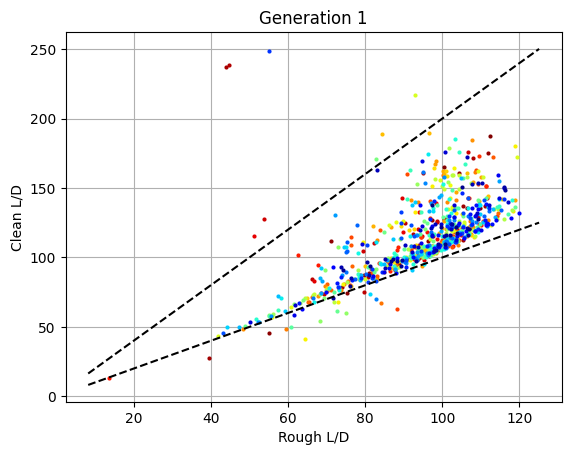

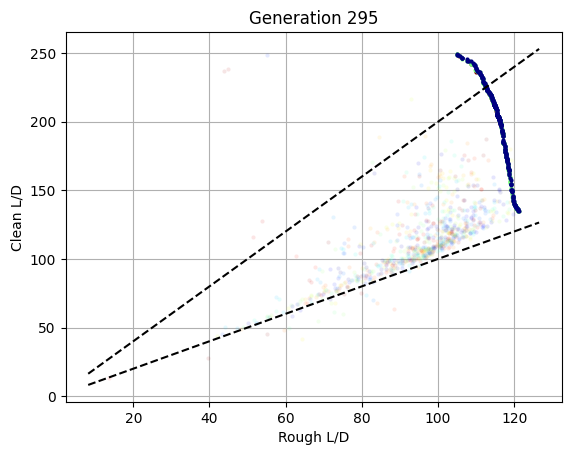

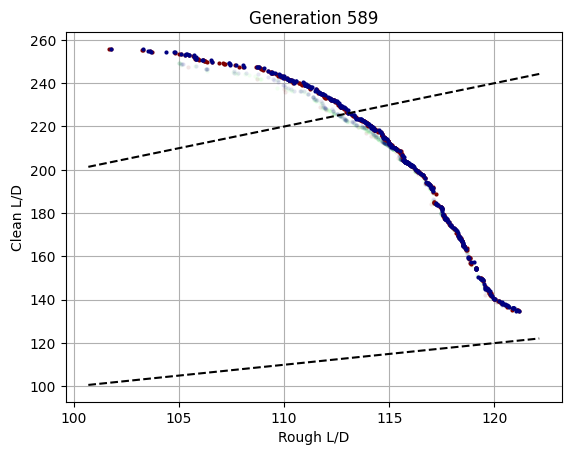

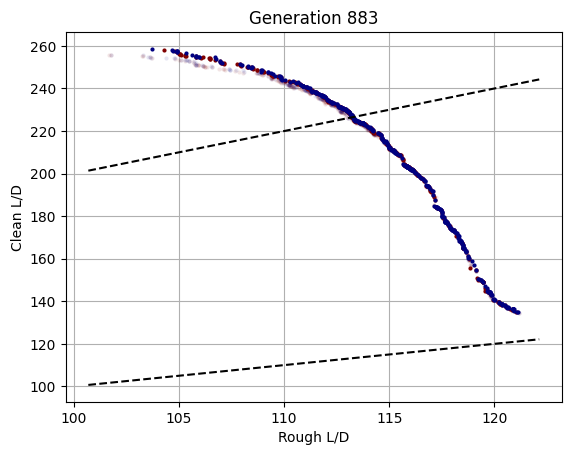

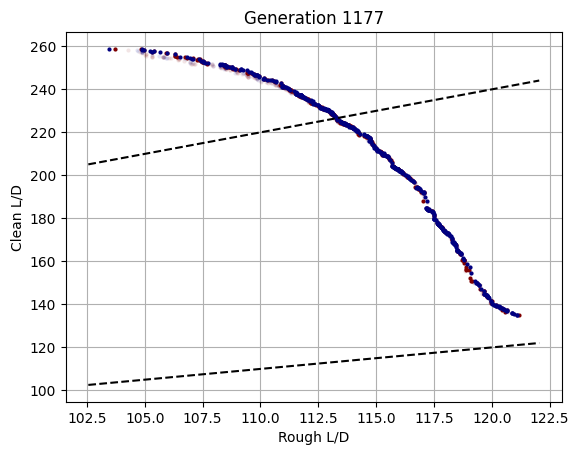

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import natsort
import numpy as np
import matplotlib.pyplot as plt
path_to_data = '/Users/codykarcher/Desktop/oso_24_special/c109_t24_l14_k16_g2000_n752__2026_01_10_14-28'
obj1ix = 22
obj2ix = 21


files = natsort.natsorted([f for f in os.listdir(path_to_data) if '.txt' in f], alg=natsort.ns.IGNORECASE)


ixs = np.linspace(1, len(files)-1, 5, dtype=int)

for ix, i in enumerate(ixs):
    f = files[i]
    # fig, ax = plt.figure()
    fig, ax = plt.subplots()

    if ix > 0:
        data_old = np.loadtxt( os.path.join(path_to_data, files[ixs[ix-1]]) )
        n_pareto = int(max([d[-1] for d in data_old]))I
        cmap = plt.get_cmap('jet', n_pareto)
        for p in list(reversed(range(1, n_pareto + 1))):
            # if p == 1:
            pareto_points = abs(data_old[ data_old[:,-1] == p ])
            plt.plot( pareto_points[:, obj1ix], pareto_points[:, obj2ix], 'o', color=cmap(p-1), label='Pareto front %d'%(p) , ms=3, mew=0, alpha = 0.1)

    data = np.loadtxt( os.path.join(path_to_data, f) )
    n_pareto = int(max([d[-1] for d in data]))
    cmap = plt.get_cmap('jet', n_pareto)
    for p in list(reversed(range(1, n_pareto + 1))):
        # if p == 1:
            pareto_points = abs(data[ data[:,-1] == p ])
            plt.plot( pareto_points[:, obj1ix], pareto_points[:, obj2ix], 'o', color=cmap(p-1), label='Pareto front %d'%(p) , ms=3, mew=0)

    plt.title('Generation %d'%(i))
    plt.xlabel('Rough L/D')
    plt.ylabel('Clean L/D')
    plt.grid(True)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    plt.plot([xlim[0], xlim[1]], [xlim[0], xlim[1]], 'k--')
    plt.plot([xlim[0], xlim[1]], [2*xlim[0], 2*xlim[1]], 'k--')




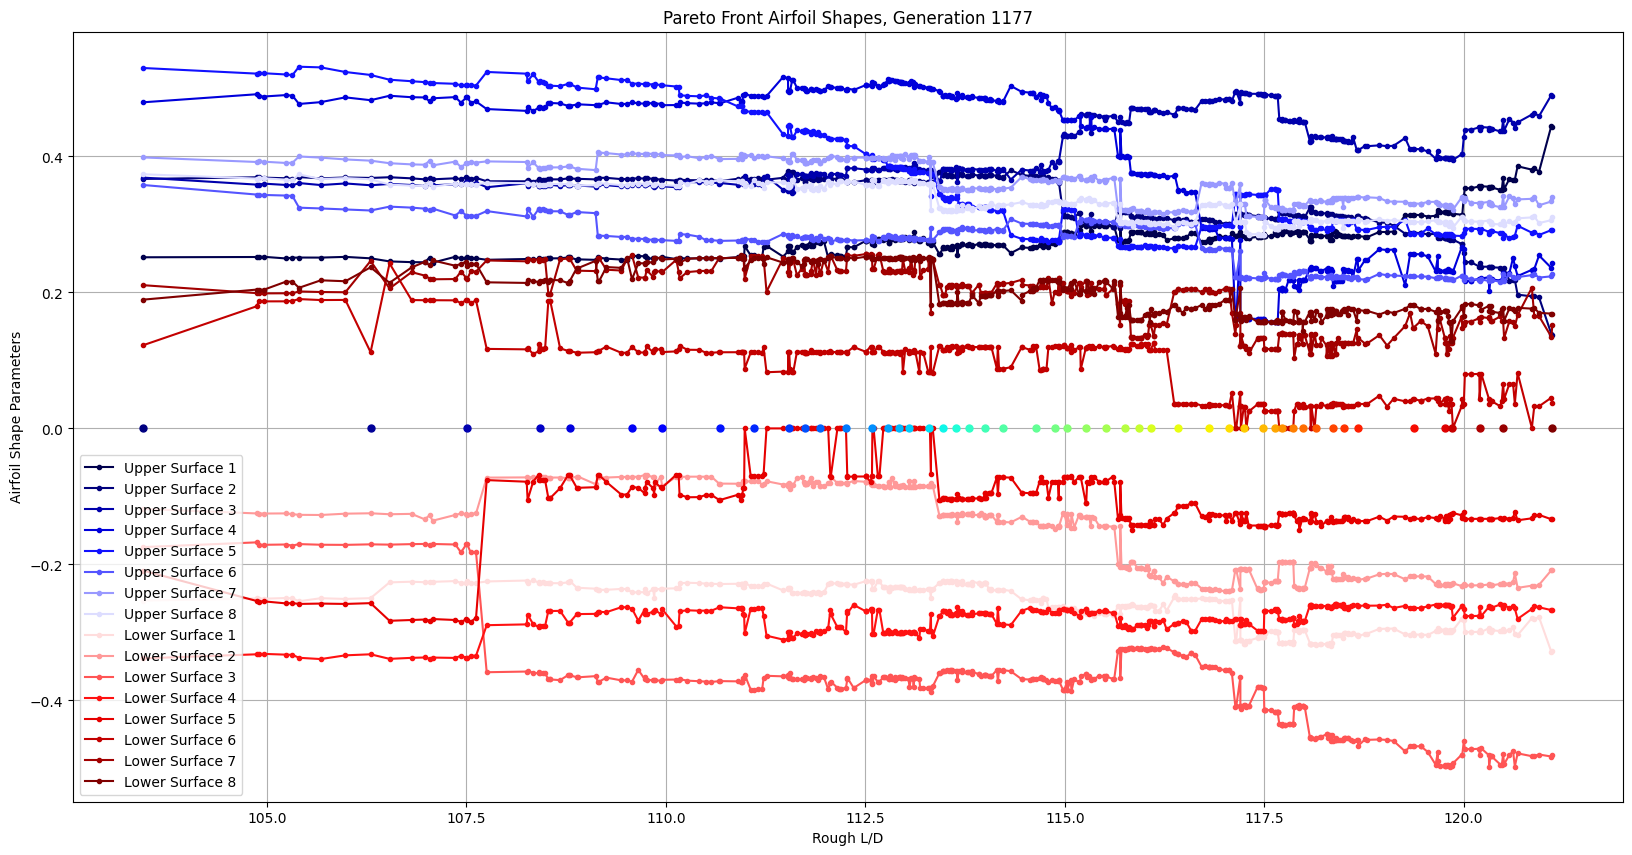

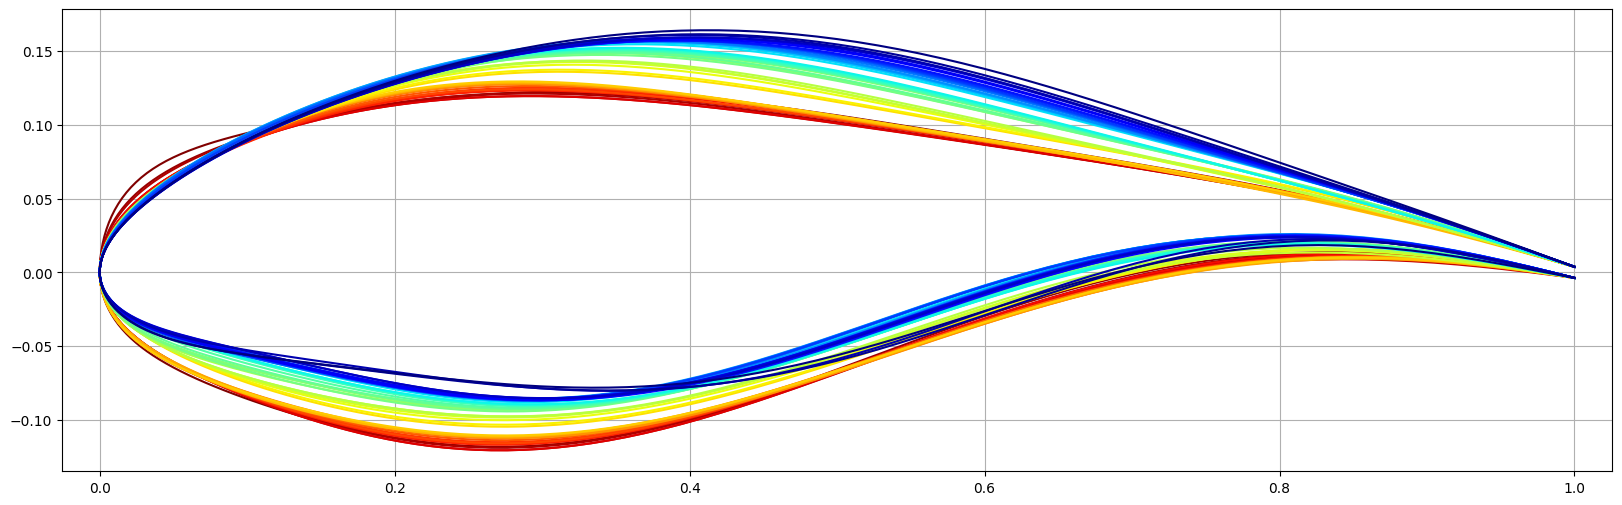

<Figure size 1200x800 with 0 Axes>

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import natsort
import numpy as np
import matplotlib.pyplot as plt
path_to_data = '/Users/codykarcher/Desktop/oso_24_special/c109_t24_l14_k16_g2000_n752__2026_01_10_14-28'
obj1ix = 22
obj2ix = 21


files = natsort.natsorted([f for f in os.listdir(path_to_data) if '.txt' in f], alg=natsort.ns.IGNORECASE)

f = files[-1]
data = np.loadtxt( os.path.join(path_to_data, f) )
pareto_points = data[ data[:,-1] == 1 ]
pareto_points = pareto_points[ np.argsort( pareto_points[:, obj1ix] ) ]
cmap = plt.get_cmap('seismic', 16)

plt.figure(figsize=(20,10))
for i in range(0,17):
    if i <= 7:
        lbl = 'Upper Surface %d'%(i+1)
        clr = cmap(i)
        plt.plot( pareto_points[:, obj1ix], pareto_points[:, i], 'o-', color=clr, label=lbl, ms=3)
    elif i<=15:
        lbl = 'Lower Surface %d'%(i-7)
        clr = cmap(i)
        plt.plot( pareto_points[:, obj1ix], pareto_points[:, i], 'o-', color=clr, label=lbl, ms=3)
    else:
        pass

nafl = 50
ixs = np.linspace(0, len(pareto_points)-1, nafl, dtype=int)
cmap = plt.get_cmap('jet', nafl)
for i in ixs:
    plt.plot(pareto_points[i, obj1ix],0,'o', color = cmap(ixs.tolist().index(i)), ms = 5)

plt.legend()
plt.xlabel('Rough L/D')
plt.ylabel('Airfoil Shape Parameters')
plt.title('Pareto Front Airfoil Shapes, Generation %d'%(len(files)-1))
plt.grid(True)

from kulfan import Kulfan

plt.figure(figsize = (20,6))

te_gap_lookup = {
    '15':  0.00196,
    '18':  0.00230,
    '21':  0.00262,
    '24':  0.00751,
    '27':  0.01012,
    '30':  0.01140,
    '33':  0.01140,
    '36':  0.01140,
}

for i in list(reversed(ixs)):
    if abs(pareto_points[i,16]) <= 0.1:
        afl = Kulfan( TE_gap=pareto_points[i,16] )
    else:
        if 't36'in path_to_data:
            afl = Kulfan( TE_gap=te_gap_lookup['36'] )
        elif 't33'in path_to_data:
            afl = Kulfan( TE_gap=te_gap_lookup['33'] )
        elif 't30'in path_to_data:  
            afl = Kulfan( TE_gap=te_gap_lookup['30'] )
        elif 't27'in path_to_data:  
            afl = Kulfan( TE_gap=te_gap_lookup['27'] )
        elif 't24'in path_to_data:  
            afl = Kulfan( TE_gap=te_gap_lookup['24'] )
        elif 't21'in path_to_data:  
            afl = Kulfan( TE_gap=te_gap_lookup['21'] )
        elif 't18'in path_to_data:  
            afl = Kulfan( TE_gap=te_gap_lookup['18'] )
        elif 't15'in path_to_data:  
            afl = Kulfan( TE_gap=te_gap_lookup['15'] )
        else:
            afl = Kulfan( )


    afl.upperCoefficients = pareto_points[i, 0:8]
    afl.lowerCoefficients = pareto_points[i, 8:16]
    plt.plot(afl.xcoordinates, afl.ycoordinates, color = cmap(ixs.tolist().index(i)),alpha=1)
    plt.axis('equal')
plt.grid(True)

# plt.figure(figsize=(12,8))
# for ppts in pareto_points:
#     if ppts[obj1ix] >= 124:
#         print(ppts)
#         afl = Kulfan( TE_gap=te_gap_lookup['21'] )
#         afl.upperCoefficients = ppts[0:8]
#         afl.lowerCoefficients = ppts[8:16]
#         plt.plot(afl.xcoordinates, afl.ycoordinates, 'r-')
#         plt.axis('equal')
#         afl.write2file('21_moment_constrained.txt')
#         break
    



# # plt.savefig('test.pgf')

# need a 3 var fit: psi, tau, clean/rough bias...  outputs chebyshev coeffs for thickness, also need camber
# should also add CL

ix=0, y_diff_sum=1.1404108864120324, ppts[obj1ix]=103.4480317901594
ix=1, y_diff_sum=1.049109317265457, ppts[obj1ix]=104.87413507633772
ix=2, y_diff_sum=1.028881396524557, ppts[obj1ix]=104.89419011784082
ix=3, y_diff_sum=1.0275974161890953, ppts[obj1ix]=104.95933820226581
ix=4, y_diff_sum=1.0283559296910114, ppts[obj1ix]=105.23492461550782
ix=5, y_diff_sum=1.0161984957668688, ppts[obj1ix]=105.31857025940599
ix=6, y_diff_sum=1.0125597811398128, ppts[obj1ix]=105.40100849484453
ix=7, y_diff_sum=0.9954484860297131, ppts[obj1ix]=105.67336466479115
ix=8, y_diff_sum=0.9796588395160589, ppts[obj1ix]=105.98176223368297
ix=9, y_diff_sum=1.0265807724766693, ppts[obj1ix]=106.29789894231347
ix=10, y_diff_sum=0.8810066295092169, ppts[obj1ix]=106.53559639008346
ix=11, y_diff_sum=0.9249958583934464, ppts[obj1ix]=106.8114375014285
ix=12, y_diff_sum=0.9084234146979304, ppts[obj1ix]=106.97634862166076
ix=13, y_diff_sum=0.8891608769765584, ppts[obj1ix]=107.03884247744728
ix=14, y_diff_sum=0.90531849587117

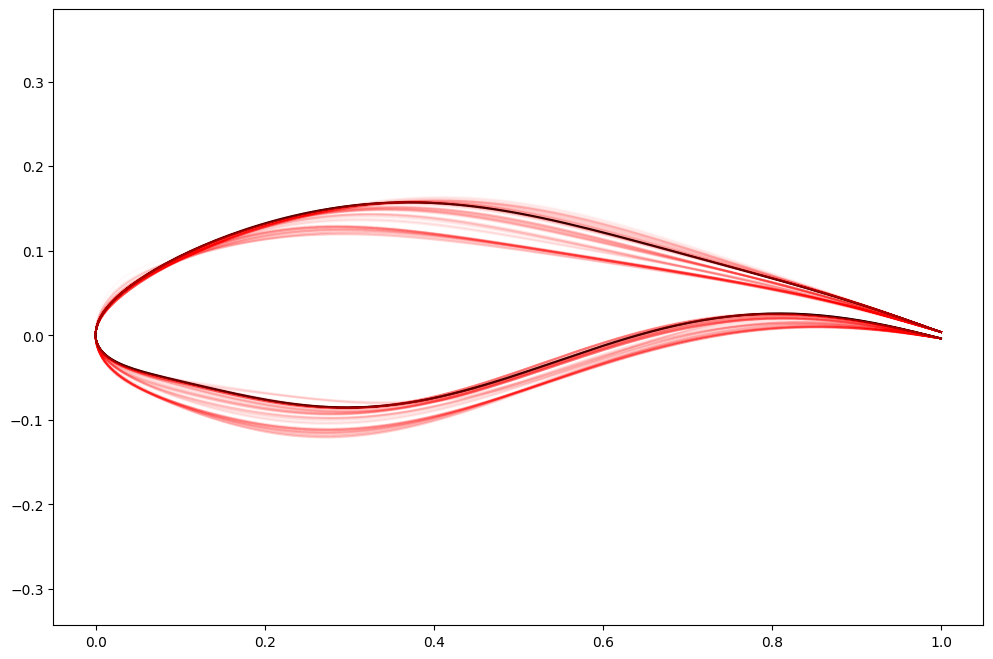

In [27]:
from pathlib import Path

target_path = Path('oso24.dat')
candidate_path = Path('21_moment_constrained.txt')

# Load target coordinates as numbers
target_coords = np.loadtxt(target_path)

plt.figure(figsize=(12,8))
afl_24 = Kulfan(TE_gap=te_gap_lookup['24'])
afl_24.readFile('oso24.dat')
plt.plot(afl_24.xcoordinates, afl_24.ycoordinates, 'k-', label='Target Airfoil')

for ix, ppts in enumerate(pareto_points):
    afl = Kulfan(TE_gap=2*3.761292e-03)#te_gap_lookup['24'])
    afl.upperCoefficients = ppts[0:8]
    afl.lowerCoefficients = ppts[8:16]
    plt.plot(afl.xcoordinates, afl.ycoordinates, 'r-', alpha = 0.01)
    plt.axis('equal')
    
    # Get coordinates as numpy array
    candidate_coords = np.array(afl.coordinates)
    
    # Compute sum of absolute differences in second column (y-coordinates)
    if candidate_coords.shape == target_coords.shape:
        y_diff_sum = np.sum(np.abs(candidate_coords[:, 1] - target_coords[:, 1]))
        print(f"ix={ix}, y_diff_sum={y_diff_sum}, ppts[obj1ix]={ppts[obj1ix]}")
    else:
        print(f"ix={ix}, shape mismatch: candidate {candidate_coords.shape} vs target {target_coords.shape}")
    
    # Check if this matches exactly
    if candidate_coords.shape == target_coords.shape and np.allclose(candidate_coords, target_coords, rtol=0.0, atol=1e-12):
        print(f"EXACT MATCH found at ix={ix}")
        break

0.00751
0.007522584
[ 2.51654516e-01  3.66851966e-01  3.68829605e-01  4.79577368e-01
  5.30007153e-01  3.57952592e-01  3.98494184e-01  3.73773702e-01
 -2.53137745e-01 -1.18411113e-01 -1.74526609e-01 -3.38176206e-01
 -2.09135285e-01  1.22366390e-01  2.10618514e-01  1.89358899e-01
  7.53784180e-03 -2.58579062e+02 -1.03237657e+02  1.00000000e+00
  3.99922811e+00  2.58789437e+02  1.03448032e+02  1.00007719e+01
  6.00077189e+00  4.20749391e-01  1.21125527e-01  2.41404381e+02
  2.45416174e+02  2.40000000e-01  3.16649977e-02  3.20393590e-02
  4.59771587e-04  6.40984714e-03  6.86961873e-03  1.41693011e-01
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.00000000e+00]
[3.94649591e-17 9.48967318e-10 9.970

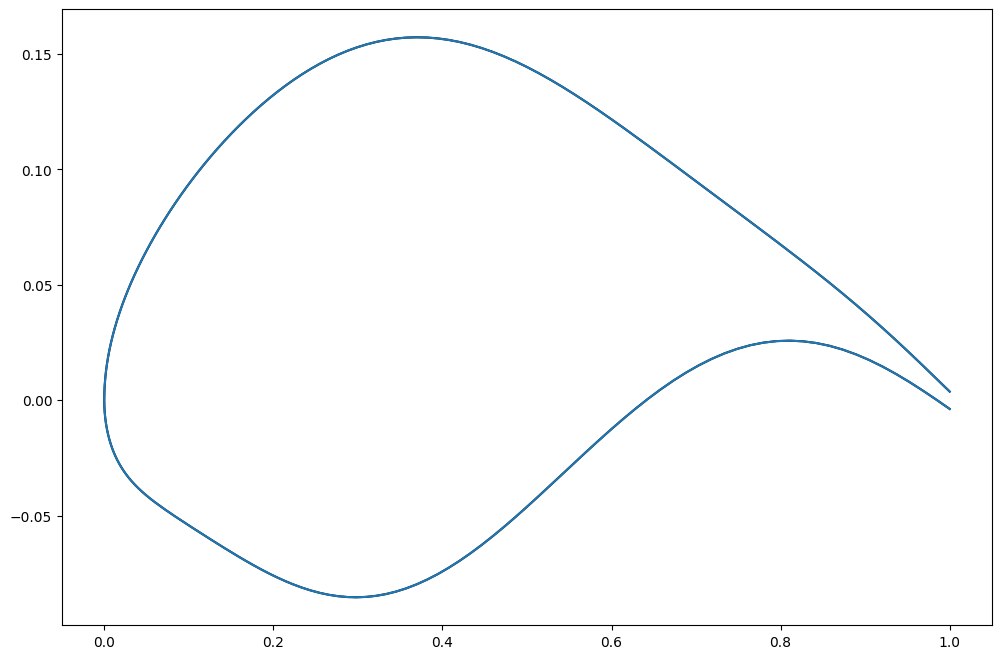

In [28]:
from pathlib import Path

print(te_gap_lookup['24'])
print(2*3.761292e-03)

target_path = Path('oso24.dat')
candidate_path = Path('21_moment_constrained.txt')

# Load target coordinates as numbers
target_coords = np.loadtxt(target_path)

plt.figure(figsize=(12,8))
afl_24 = Kulfan(TE_gap=te_gap_lookup['24'])
afl_24.readFile('oso24.dat')
plt.plot(afl_24.xcoordinates, afl_24.ycoordinates, 'k-', label='Target Airfoil')

for ix, ppts in enumerate(pareto_points[114:115]):
    print(pareto_points[ix])
    afl = Kulfan(TE_gap=2*3.761292e-03)#te_gap_lookup['24'])
    afl.upperCoefficients = ppts[0:8]
    afl.lowerCoefficients = ppts[8:16]
    plt.plot(afl.xcoordinates, afl.ycoordinates)
    # plt.axis('equal')
    afl.write2file('candidate_airfoil.txt')
    
    # Get coordinates as numpy array
    candidate_coords = np.array(afl.coordinates)
    
    # Compute sum of absolute differences in second column (y-coordinates)
    if candidate_coords.shape == target_coords.shape:
        print(np.abs(candidate_coords[:, 1] - target_coords[:, 1]))
        y_diff_sum = np.sum(np.abs(candidate_coords[:, 1] - target_coords[:, 1]))
        print(f"ix={ix}, y_diff_sum={y_diff_sum}")
    else:
        print(f"ix={ix}, shape mismatch: candidate {candidate_coords.shape} vs target {target_coords.shape}")
    
    # Check if this matches exactly
    if candidate_coords.shape == target_coords.shape and np.allclose(candidate_coords, target_coords, rtol=0.0, atol=1e-12):
        print(f"EXACT MATCH found at ix={ix}")
        break

Manual Selection of the airfoil on this front, rough L/D >112.5(076)

TE gap of 0.007522584

